## Model Training On Synthetic Data

In [54]:
# Import modules
import pandas as pd
import numpy as np

### Load Dataset

In [55]:
transactions_data_train = pd.read_csv("data/train.csv")
print(transactions_data_train.head())

       amount  hour  day_of_week merchant_category  is_fraud
0  214.056124    10            2            retail         0
1  470.044641    14            1           grocery         0
2   59.567221     9            4           grocery         0
3   28.190464    21            0            retail         0
4   45.258306    16            3           grocery         0


## Data Preparation 

### One Hot Encoding

Before trainng any machine learning model, the data has to be in the proper format for the task at hand. Machine learning models work only with numerical data and don't now what to do with text data. Here the merchant category feature is encoded using One Hot Encoding.

In [56]:
transactions_data_train = pd.get_dummies(transactions_data_train, columns=["merchant_category"], dtype="int")
print(transactions_data_train.head())

       amount  hour  day_of_week  is_fraud  merchant_category_grocery  \
0  214.056124    10            2         0                          0   
1  470.044641    14            1         0                          1   
2   59.567221     9            4         0                          1   
3   28.190464    21            0         0                          0   
4   45.258306    16            3         0                          1   

   merchant_category_online  merchant_category_restaurant  \
0                         0                             0   
1                         0                             0   
2                         0                             0   
3                         0                             0   
4                         0                             0   

   merchant_category_retail  merchant_category_travel  
0                         1                         0  
1                         0                         0  
2                         

### Train and Test Splits

Before trainig any machine learnig model the data should be split into training and testing sets. This is done so we can use one part of the data to train the model and the other part which remains hidden during training is for testing the model's performance on unseen data. A good rule of thumb is to use 80% of the data for traiing and 20% of the data for testing or validation of the model. Here `train.csv` is spit into 80% traing data and 20% validation data for hyperparameter tuning and evaluation. `Test.csv` will be used for the final evaluation of the model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Predictor features
X = transactions_data_train.drop("is_fraud", axis=1)

# Target labels - fraud, not fraud
y = transactions_data_train["is_fraud"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

is_fraud
0    6272
1     128
Name: count, dtype: int64
is_fraud
0    1568
1      32
Name: count, dtype: int64


### Standardizing Numerical Features

Some machine learning models require numerical features to be on the same scale inorder to make proper predictions. As noted during exploration of the data some of the numerical features are on vastly different scales and are in need of standardization. Standard Scaler is used here to scale all of the numerical features to have a mean of zero and a unit of variance. This is done after train-test splitting to prevent __data leakage__.

In [58]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Model Building

It's time to try out a few models and see how they perform on the task. Let's start simple and increase model complexity as we go. Bellow a few popular machine learning classification algorithms are imported 

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

### Evaluation Metrics

Given the imbalanced dataset, the suitable metric for evaluating the models is __average precision score__

__AP__ summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

$$ AP = \sum_{n} (R_n - R_{n-1})P_n $$

where $ P_n $ and $ R_n $ are the precision and recall at the nth threshold. This implementation is not interpolated and is different from computing the area under the precision-recall curve with the trapezoidal rule, which uses linear interpolation and can be too optimistic.

In [60]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, precision_recall_curve

### Logistic Regression

Bellow the model was trained with default prameters and achived 49% on the training set and 62% on the validation set which is promissing. Hyperpamrameter tuning may improve model performance if applied later on.

In [61]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_proba_train = log_reg.predict_proba(X_train_scaled)
train_score = average_precision_score(y_train, y_proba_train[:, 1])

print(f"Train set score: {train_score}")

y_proba_val = log_reg.predict_proba(X_val_scaled)
val_score = average_precision_score(y_val, y_proba_val[:, 1])

print(f"Validation set score: {val_score}")

Train set score: 0.49058320948694656
Validation set score: 0.6221484086944218


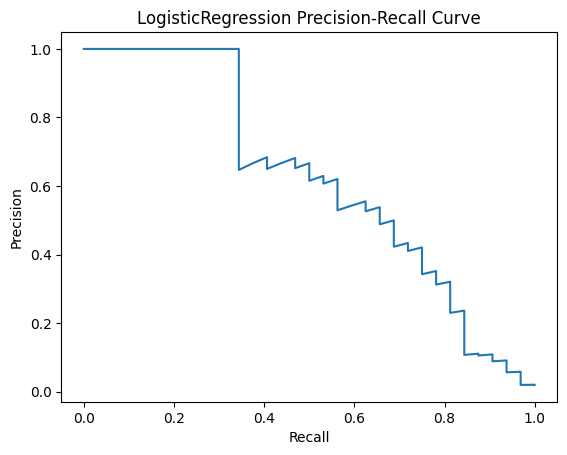

In [62]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_val, y_proba_val[:, 1], pos_label=1)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LogisticRegression Precision-Recall Curve")
plt.show()

### K-Nearest Neighbors Classifier

Bellow the model was trained using default parameters and achived a score of 62% on the training set and 36% on the validation set which may be a sign of overfitting to the trainng set. Adjusting the `n_neighbors` hyperparmeter may increase model performance. 

In [63]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_scaled, y_train)

y_proba_train = knn_clf.predict_proba(X_train_scaled)
train_score = average_precision_score(y_train, y_proba_train[:, 1])

print(f"Training set score: {train_score}")

y_proba_val = knn_clf.predict_proba(X_val_scaled)
val_score = average_precision_score(y_val, y_proba_val[:, 1])

print(f"Validation set score: {val_score}")

Training set score: 0.6268993100825728
Validation set score: 0.3610931647940075


### Linear Support Vector Classifier

Bellow the model was trained using defaut parameters and achived a score of 46% on the training set and 56% on the validation set which is promissing. The slightly lower training score is caused by the fact that `LinearSVC` uses `L2` regulariztion by default which makes the model slightly underfit on the training set.

In [64]:
linear_svc = LinearSVC(random_state=42)
linear_svc.fit(X_train_scaled, y_train)

y_proba_train = linear_svc.decision_function(X_train_scaled)
train_score = average_precision_score(y_train, y_proba_train)

print(f"Training set score: {train_score}")

y_proba_val = linear_svc.decision_function(X_val_scaled)
val_score = average_precision_score(y_val, y_proba_val)

print(f"Validation set score: {val_score}")

Training set score: 0.46565126621591485
Validation set score: 0.5642262803019147


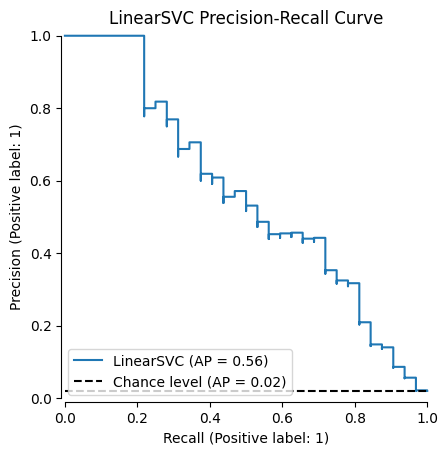

In [65]:
display = PrecisionRecallDisplay.from_predictions(
    y_val, 
    y_proba_val, 
    name="LinearSVC", 
    plot_chance_level=True, 
    despine=True
)

_ = display.ax_.set_title("LinearSVC Precision-Recall Curve")

### Random Forest Classifier

Bellow the model was trained using default parameters and achived a score of 100% on the training set and 50% on the validation set which clearly indicates that it's overfitting on the training set. Lowering model complexity during hyperparameter tuning may solve this issue

In [66]:
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)

y_proba_train = forest_clf.predict_proba(X_train)
train_score = average_precision_score(y_train, y_proba_train[:, 1])

print(f"Training set score: {train_score}")

y_proba_val = forest_clf.predict_proba(X_val)
val_score = average_precision_score(y_val, y_proba_val[:, 1])

print(f"Validation set score: {val_score}")

Training set score: 1.0
Validation set score: 0.5069880357401684


## Hyperparameter Tuning

Let's try squeezing more performance form the models by tuning some of ther hyperparameters
by using random searching with cross-validation. Since this method picks random values for each hyperparameter from a predefined grid of values it doesn't guarnatee the optimal values but it's much faster than other alternatives.

In [67]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

### Logistic Regression

In [68]:
log_reg = LogisticRegression(random_state=42)

param_dist = {
    "C": np.linspace(0, 1, 10),
    "fit_intercept": [True, False],
    "class_weight": [None, "balanced"]
}

rand_search = RandomizedSearchCV(
    log_reg, 
    param_distributions=param_dist, 
    scoring="average_precision", 
    n_iter=10, 
    cv=10, 
    n_jobs=-1, 
    random_state=42,
    error_score="raise"
)

rand_search.fit(X_val_scaled, y_val)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([0. ..., 1. ]), 'class_weight': [None, 'balanced'], 'fit_intercept': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 `

In [69]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyperparameters: {best_prams}")
print(f"Best score: {best_score}")

Best hyperparameters: {'fit_intercept': True, 'class_weight': 'balanced', 'C': np.float64(0.1111111111111111)}
Best score: 0.5970064869074015


### K-Nearest Neighbors Classifier

Bellow the `n_estimators` hyper parameter is tuned. After hyperparameter tuning the best model achived a score of 48% which is slightly better than before but is still worse than random guessing.

In [70]:
knn_clf = KNeighborsClassifier()

param_dist = {
    "n_neighbors": [1, 2, 3, 4],
}

rand_search = RandomizedSearchCV(
    knn_clf, 
    param_distributions=param_dist,
    scoring="average_precision", 
    n_iter=4, 
    cv=10, 
    n_jobs=-1, 
    random_state=42,
    error_score="raise"
)

rand_search.fit(X_val_scaled, y_val)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'n_neighbors': [1, 2, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose ver

In [71]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyperparameters: {best_prams}")
print(f"Best score: {best_score}")

Best hyperparameters: {'n_neighbors': 4}
Best score: 0.4844940476190477


### Linear Support Vector Classifier

Bellow the `C` , `loss`, `fit_intercept` and  `class_weight` are tuned. After hyperparameter tuning the best model achived a score of 58% which is slightly better than before but still not good enough

In [74]:
linear_svc = LinearSVC(random_state=42)

param_dist = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "loss": ["hinge", "squared_hinge"],
    "fit_intercept": [True, False],
    "class_weight": [None, "balanced"]
}

rand_search = RandomizedSearchCV(
    linear_svc, 
    param_distributions=param_dist,
    scoring="average_precision", 
    n_iter=5, 
    cv=10, 
    n_jobs=-1, 
    random_state=42,
    error_score="raise"
)

rand_search.fit(X_val_scaled, y_val)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'fit_intercept': [True, False], 'loss': ['hinge', 'squared_hinge']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [75]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best parameters: {best_prams}")
print(f"Best score: {best_score}")

Best parameters: {'loss': 'hinge', 'fit_intercept': True, 'class_weight': 'balanced', 'C': 0.001}
Best score: 0.5814741339050096


### Random Forest Classifer

In [82]:
forest_clf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [50, 70, 90],
    "max_depth": [2, 4, 6],
    "criterion": ["gini", "entropy", "log_loss"],
    "min_samples_leaf": [2, 4, 6],
    "min_samples_split": [2, 4, 6],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

rand_search = RandomizedSearchCV(
    forest_clf, 
    param_distributions=param_dist,
    scoring="average_precision",
    n_iter=3,
    cv=10,
    random_state=42,
    n_jobs=-1,
    error_score="raise"
)

rand_search.fit(X_val, y_val)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced', ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 4, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [83]:
best_model = rand_search.best_estimator_
best_prams = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best paramters: {best_prams}")
print(f"Best score: {best_score}")

Best paramters: {'n_estimators': 70, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
Best score: 0.6841810008107199
